In [1]:
print('Running imports...')

import torch # long
import os
import numpy as np
import lightning as L
from torch.utils.data import DataLoader, TensorDataset, random_split
import xarray as xr
from models.model import Wang2024
from lightning.pytorch.loggers import WandbLogger
import wandb
from models.lightning import LitCNN_quantiles, AttributableTrainer, ConfusionMatrix, BetterConfusionMatrix, PrecisionRecallClass9
from models.losses import DistribLoss, PinballLoss, WeightedOrdinalLoss, logits_to_class_probs
import random
import matplotlib
from models.data import get_input_data, get_input_data_small
import pandas as pd
import cartopy.crs as ccrs
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
# from models.attributions import log_attributions
from captum.attr import IntegratedGradients

matplotlib.use('tkagg')


def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

learning_rate = 0.001
batch_size = 256
num_epochs = 20
device = 'cuda:1'
input_variable = [ 'u850','v850']
groups = 1
loss_fn = 'mse'
region_predicted = 14
type_prediction='quantiles'
lags = 0
input_type='small'
attribute_test = True

match loss_fn:
    case 'distrib':
        loss = DistribLoss()
    case 'mse':
        loss = torch.nn.MSELoss()
    case 'cross_entropy':
        loss = torch.nn.CrossEntropyLoss()
    case 'weighted_cross_entropy':
        loss = torch.nn.CrossEntropyLoss(weight=torch.Tensor([1,1,1,1,1,1,1,1,1,1]))
    case 'pinball90':
        loss = PinballLoss(.9)
    case 'corn':
        loss = corn_loss
    case 'weighted_ordinal':
        loss = WeightedOrdinalLoss(num_classes=10, extreme_weight=1)

   

if type_prediction == 'quantiles':
    num_classes = 10
elif type_prediction == 'regression':
    num_classes =  1


Running imports...


In [2]:
%matplotlib inline

In [3]:


config = {
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "num_classes": num_classes,
    "learning_rate":learning_rate,
    "input_variable" :input_variable,
    "number_variables":len(input_variable),
    "groups" : groups,
    "lags":lags,
    "region_predicted":region_predicted,
    "type_prediction":type_prediction,
    "loss_fn":loss_fn,
    "input_type":input_type,
    }



wandb_logger = WandbLogger(project="Predict-rain-WNorway", 
                           save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                           dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb",
                           config=config, name=f"CNN-{type_prediction} {'-'.join(input_variable)} lag {lags}")
# wandb_logger = WandbLogger(project="Predict-rain-WNorway", config=config, name="Truth")


In [4]:
ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x64.nc').data_normed.sel(var_name=input_variable)
wind_data = ds_in.values
wind_data

array([[[[-1.14967550e+00, -1.08849661e+00, -1.14418236e+00, ...,
          -3.50475048e-01, -3.07521161e-02,  1.83206568e-01],
         [-8.17004562e-01, -7.92169512e-01, -7.50113521e-01, ...,
          -5.16334777e-01, -4.68314454e-01, -5.56173991e-01],
         [ 1.63722183e-01,  1.59400980e-01,  1.95018150e-01, ...,
          -1.75387580e-01, -3.55760444e-01, -8.25107711e-01],
         ...,
         [-5.04939348e-01, -5.74648000e-01, -6.29811528e-01, ...,
           2.57313359e-01,  3.32235524e-01,  3.63897967e-01],
         [-2.34725534e-01, -2.68334982e-01, -2.94595433e-01, ...,
          -3.44713874e-01, -2.98714070e-01, -2.23930152e-01],
         [-1.29756958e-01, -1.30331493e-01, -1.30303043e-01, ...,
          -3.95156460e-01, -3.64578014e-01, -3.28729406e-01]],

        [[ 3.48854166e-01,  3.21033925e-01,  2.06295250e-01, ...,
          -3.67938864e-01, -1.35799046e-01,  1.65417609e-01],
         [ 3.03836857e-01,  3.29680687e-01,  2.42655985e-01, ...,
          -2.08643157e

In [5]:
seq_length = 5
def create_sequences(data, labels, seq_length=seq_length):
    X, Y = [], []
    for i in range(len(data) - seq_length-1):
        X.append(data[i : i + seq_length])  # (seq_length, 2, 32, 32)
        Y.append(labels[i + seq_length+1])  # Corresponding label
    return np.array(X), np.array(Y)

# Assume we have corresponding quantile labels for each time step
with xr.open_dataarray('/Data/gfi/users/rogui7909/era5_rain_norge/ERA5land_daily_TP_indices.nc', chunks = dict(longitude=20, latitude=20)) as ds_out:
    data_out = ds_out.sel(mask_id=region_predicted)
    if type_prediction=='quantiles':
        data_out = (data_out.rank('time', pct=True)//.1).astype(int)
    quantile_labels = data_out.values


# Create input-output sequences
X_seq, Y_seq = create_sequences(wind_data, quantile_labels, seq_length=5)

# Convert to PyTorch tensors
X_seq = torch.tensor(X_seq, dtype=torch.float32)  # Shape: (N, seq_length, 2, 32, 32)
Y_seq = torch.tensor(Y_seq, dtype=torch.long)  # Shape: (N,)

In [6]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X_seq, Y_seq)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# use 20% of data for test
trainvalid_set_size = int(len(dataset) * 0.8)
test_set_size = len(dataset) - trainvalid_set_size
# split the train set into two
seed = torch.Generator().manual_seed(42)
trainvalid_set, test_set = random_split(dataset, [trainvalid_set_size, test_set_size], generator=seed)

# use 20% of training data for validation
train_set_size = int(len(trainvalid_set) * 0.8)
valid_set_size = len(trainvalid_set) - train_set_size

# split the train set into two
seed = torch.Generator().manual_seed(43)
train_set, valid_set = random_split(trainvalid_set, [train_set_size, valid_set_size], generator=seed)


train_loader = DataLoader(train_set, batch_size=batch_size)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

ds_test = ds_in.shift(time=seq_length).isel(time=test_loader.dataset.indices)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl

class ConvLSTM(L.LightningModule):
    def __init__(self, num_classes=1, in_channels=2, conv_filters=32, lstm_hidden=64, seq_length=5, lr=1e-4):
        super().__init__()
        self.save_hyperparameters()

        # Convolutional feature extractor
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, conv_filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # Output: (B, conv_filters, 16, 16)
            nn.Conv2d(conv_filters, conv_filters * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # Output: (B, conv_filters*2, 8, 8)
        )

        # LSTM layer
        self.lstm = nn.LSTM(input_size=(conv_filters * 2) * 16 * 8 , hidden_size=lstm_hidden, batch_first=True)

        # Classification head
        self.fc = nn.Linear(lstm_hidden, num_classes)
        self.loss_fn = nn.CrossEntropyLoss()
        self.lr = lr

    def forward(self, x):
        batch_size = x.shape[0]
        seq_length = x.shape[1]

        # Extract spatial features for each time step
        conv_out = []
        for t in range(seq_length):
            # Extract features for time step t
            time_step = x[:, t, :, :, :]  # Shape: (B, 2, 32, 32)
            time_step = self.conv(time_step)  # Shape: (B, conv_filters*2, 8, 8)
            time_step = time_step.view(batch_size, -1)  # Flatten to (B, conv_filters*2*8*8)
            conv_out.append(time_step)

        # Stack all time steps (Shape: (B, seq_length, feature_dim))
        conv_out = torch.stack(conv_out, dim=1)

        # Process with LSTM
        lstm_out, _ = self.lstm(conv_out)  # (B, seq_length, lstm_hidden)
        lstm_out = lstm_out[:, -1]  # Use last time step output

        # Classification
        return self.fc(lstm_out)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(dim=-1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        return optim.AdamW(self.parameters(), lr=self.lr)

    def attribute_step(self, batch, batch_idx, attribution_method=None, target=9, baselines=0, method_kwargs = dict()):
        features, true_labels = batch
        features.requires_grad = True
        if attribution_method is None:
            attribution_method = IntegratedGradients(self.model, **method_kwargs)
        attribution = attribution_method.attribute(features, target=target, baselines=baselines)
        return attribution.detach()

In [11]:


config = {
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "num_classes": num_classes,
    "learning_rate":learning_rate,
    "input_variable" :input_variable,
    "number_variables":len(input_variable),
    "groups" : groups,
    "lags":lags,
    "region_predicted":region_predicted,
    "type_prediction":type_prediction,
    "loss_fn":loss_fn,
    "input_type":input_type,
    }



wandb_logger = WandbLogger(project="Predict-rain-WNorway", 
                           save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                           dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb",
                           config=config, name=f"CNN-{type_prediction} {'-'.join(input_variable)} lag {lags}")
# wandb_logger = WandbLogger(project="Predict-rain-WNorway", config=config, name="Truth")

# print('Loading data ...')
# if input_type=='small':
#     image_size = 32*32
#     train_loader, valid_loader, test_loader, ds_test = get_input_data_small(config['input_variable'], config['region_predicted'], config['type_prediction'], config['batch_size'], lags=lags)
# elif input_type=='big':
#     image_size=100*256
#     train_loader, valid_loader, test_loader = get_input_data(config['input_variable'], config['region_predicted'], config['type_prediction'], config['batch_size'], lags=lags)
 
print('Data ready')

callbacks=[]

trainer = AttributableTrainer(limit_train_batches=100, max_epochs=num_epochs, logger=wandb_logger, 
                              log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/", devices=1,
                              callbacks=callbacks)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data ready


In [12]:
model = ConvLSTM(in_channels=2)
trainer.fit(model, train_loader, valid_loader)


/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | conv    | Sequential       | 19.1 K | train
1 | lstm    | LSTM             | 2.1 M  | train
2 | fc      | Linear           | 65     | train
3 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
2.1 M     Trainable params
0         Non-trainable params
2.1 M     Total params
8.533     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/conda/conda-bld/pytorch_1729647329220/work/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [0,0,0] Assertion `t >= 0 && t < n_classes` failed.
/opt/conda/conda-bld/pytorch_1729647329220/work/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [1,0,0] Assertion `t >= 0 && t < n_classes` failed.
/opt/conda/conda-bld/pytorch_1729647329220/work/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [2,0,0] Assertion `t >= 0 && t < n_classes` failed.
/opt/conda/conda-bld/pytorch_1729647329220/work/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [7,0,0] Assertion `t >= 0 && t < n_classes` failed.
/opt/conda/conda-bld/pytorch_1729647329220/work/aten/src/ATen/native/cuda/Loss.cu:250: nll_loss_forward_reduce_cuda_kernel_2d: block: [0,0,0], thread: [8,0,0] Assertion `t >= 0 && t < n_cl

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [17]:
baselines = torch.stack([test_loader.dataset.dataset.tensors[0].mean(dim=0)]).shape

In [88]:
from tqdm.notebook import tqdm

input_list = []
truth_list = []
pred_list = []
for batch in tqdm(test_loader):
    x,y = batch
    pred = model(x)
    truth_list.append(y)
    pred_list.append(pred)
    input_list.append(x) 
inputs = torch.cat(input_list)
truth = torch.cat(truth_list)
pred = torch.argmax(torch.cat(pred_list), dim=1)

  0%|          | 0/18 [00:00<?, ?it/s]

In [89]:
baselines = torch.stack([inputs.mean(dim=0)])

In [90]:
baselines.shape

torch.Size([1, 5, 2, 32, 32])

In [91]:
attr = ig.attribute(inputs[true_indices], baselines=baselines, target=9)

In [71]:
attr.shape

torch.Size([311, 5, 2, 32, 32])

In [92]:
attribution_da = xr.DataArray(attr, 
                            dims=['time','lags','var_name','latitude','longitude'], 
                            coords={'lags':[5,4,3,2,1],**ds_test.isel(time=true_indices).coords})


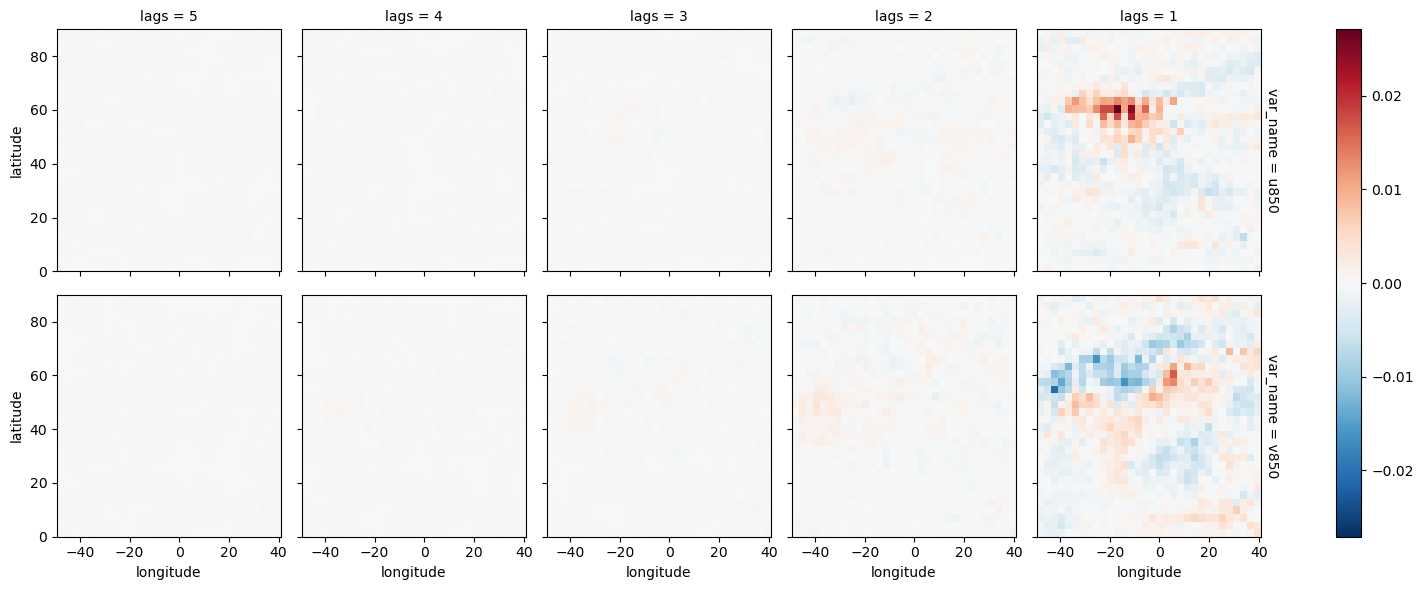

wandb: 
wandb: 🚀 View run CNN-quantiles u850-v850 lag 0 at: https://wandb.ai/rguilcas-university-of-bergen/Predict-rain-WNorway/runs/1cyyxryf
wandb: Find logs at: ../../../../../Data/gfi/users/rogui7909/wanbd_logs/wandb/run-20250221_144741-1cyyxryf/logs


In [94]:
attribution_da_season = attribution_da.groupby('time.season').mean()

(attribution_da_season).sel(season='DJF').plot(col='lags', row='var_name', robust=False)

In [38]:
true_indices = np.where((truth==9)&(pred==9))[0]

In [46]:
data_in_true_target = torch.Tensor(ds_test.isel(time=true_indices).values)
data_out_true_target = torch.Tensor(pred[true_indices])
dataset_attr = TensorDataset(data_in_true_target,data_out_true_target)
attribution_loader = DataLoader(dataset_attr, batch_size=10)

baseline = torch.stack([test_loader.dataset.dataset.tensors[0].mean(dim=0)])
ig = IntegratedGradients(model)
# nt = NoiseTunnel(ig)
# dl = DeepLift(model)

attribution_ig = trainer.attribue(attribution_loader, baselines=baseline, target=9, attribution_method=ig)
# attribution_nt = model(attribution_loader, baselines=baseline, target=target, attribution_method=nt)
# attribution_dl = model(attribution_loader, baselines=baseline, target=target, attribution_method=dl)

attribution_da = xr.DataArray([attribution_ig], 
                            dims=['attr_method']+list(ds_test.dims), 
                            coords={'attr_method':['IntegratedGradients'], 
                                    **ds_test.isel(time=true_indices).coords})


AttributeError: 'AttributableTrainer' object has no attribute 'attribue'